# Lab 2 - Class Weight and Final Comparison

**Phần phụ trách: Trung**

Notebook trình bày xử lý mất cân bằng bằng `class_weight`, kết quả validation, confusion matrix, so sánh mô hình của nhóm và kết luận. Logic thực nghiệm nằm trong `src/trung_class_weight.py`.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'src').is_dir() and (candidate / 'data' / 'bank-full.csv').is_file():
            return candidate
    raise FileNotFoundError('Không tìm thấy thư mục gốc dự án.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
RESULTS_DIR = PROJECT_ROOT / 'outputs' / 'results'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
print(f'Project root: {PROJECT_ROOT}')

Project root: /run/media/gloryh/Glory.H/02_Documents/Glory.H_Code/Studying_HCMUS/Introduction_To_AI/lab-2


## 1. Thiết kế thí nghiệm

Giữ nguyên official split 80/20. Khóa các tham số cấu trúc do workflow Hau chọn, sau đó chỉ chọn `class_weight` bằng F1 lớp `yes` trên stratified 5-fold CV của training set. Test set chỉ được dùng một lần sau khi weight đã khóa.

In [2]:
from src.trung_class_weight import run_trung_class_weight_workflow

hau_summary_path = RESULTS_DIR / 'hau_best_parameters.json'
if not hau_summary_path.is_file():
    raise FileNotFoundError('Thiếu Hau artifacts; hãy chạy run_all.py trước.')
structural_parameters = json.loads(hau_summary_path.read_text(encoding='utf-8'))['best_parameters']

required = [
    RESULTS_DIR / 'trung_class_weight_validation.csv',
    RESULTS_DIR / 'trung_best_class_weight.json',
    RESULTS_DIR / 'trung_weighted_tree_metrics.csv',
    RESULTS_DIR / 'team_model_comparison.csv',
]
if any(not path.is_file() for path in required):
    display(run_trung_class_weight_workflow(structural_parameters=structural_parameters))
else:
    print('Đã tải artifacts có sẵn; không chạy lại validation.')

validation = pd.read_csv(required[0])
summary = json.loads(required[1].read_text(encoding='utf-8'))
metrics = pd.read_csv(required[2]).set_index('Metric')['Result']
comparison = pd.read_csv(required[3])

Đã tải artifacts có sẵn; không chạy lại validation.


## 2. Mất cân bằng lớp

In [3]:
from src.data import load_bank_data

frame = load_bank_data()
counts = frame['y'].value_counts().reindex(['no', 'yes'])
figure, axis = plt.subplots(figsize=(7.5, 4.5))
bars = axis.bar(counts.index, counts.values, color=['#2563EB', '#F59E0B'])
axis.bar_label(bars, labels=[f'{value:,}' for value in counts], padding=3)
axis.set_title('Phân bố target Bank Marketing')
axis.set_ylabel('Số quan sát')
axis.spines[['top', 'right']].set_visible(False)
plt.show()
display((counts / counts.sum()).rename('Proportion').to_frame().style.format('{:.2%}'))

/tmp/ipykernel_41710/3082584362.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,Proportion
y,
no,88.30%
yes,11.70%


## 3. Validation các class weight

class_weight_label,mean_cv_precision,mean_cv_recall,mean_cv_f1,mean_cv_roc_auc
nan,0.5986,0.4670,0.5243,0.8992
balanced,0.3894,0.8662,0.5373,0.9005
"no=1, yes=1.5",0.5562,0.5921,0.5735,0.8965
"no=1, yes=2",0.5319,0.6483,0.5841,0.8963
"no=1, yes=3",0.4824,0.7405,0.5842,0.8972
"no=1, yes=4",0.4479,0.7930,0.5722,0.9007
"no=1, yes=5",0.4169,0.8138,0.5511,0.8953


Weight được chọn: no=1, yes=3


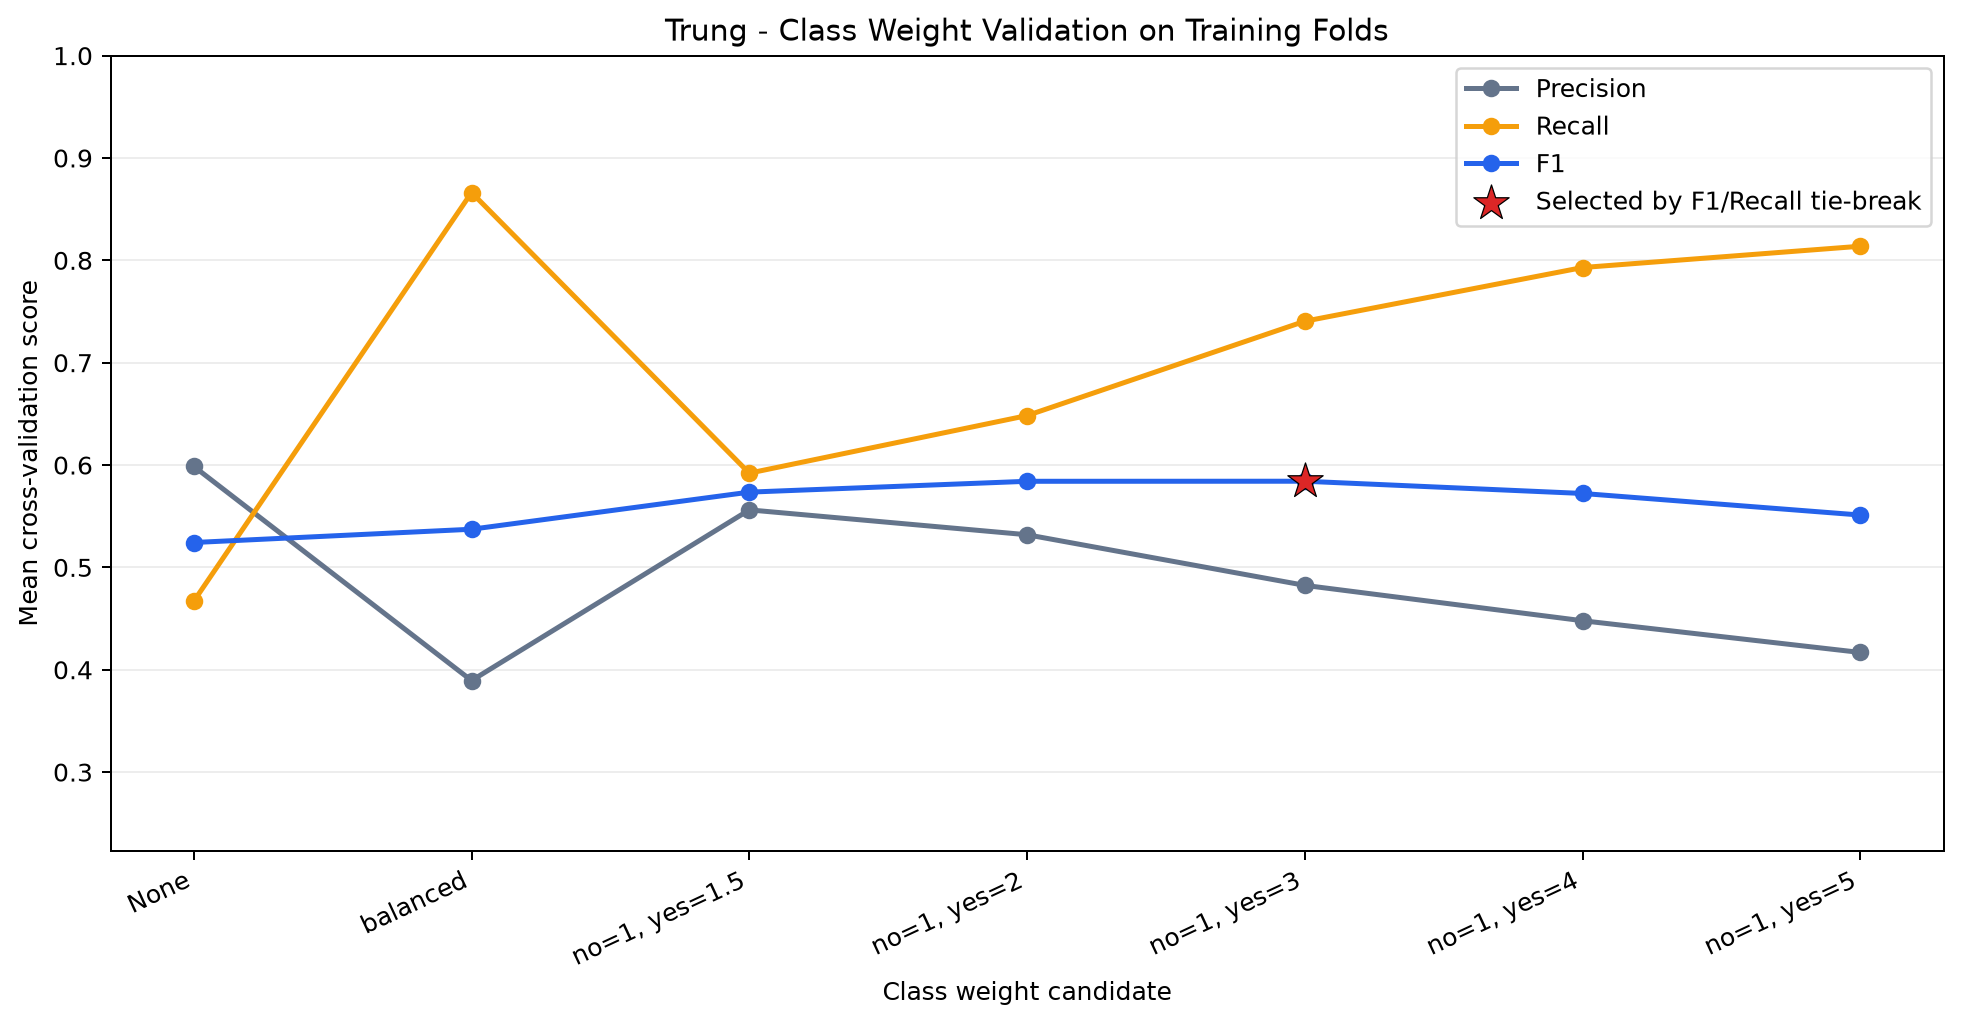

In [4]:
display(
    validation[['class_weight_label', 'mean_cv_precision', 'mean_cv_recall', 'mean_cv_f1', 'mean_cv_roc_auc']]
    .style.format({column: '{:.4f}' for column in validation.columns if column.startswith('mean_')})
    .background_gradient(subset=['mean_cv_f1'], cmap='Blues')
    .hide(axis='index')
)
print('Weight được chọn:', summary['selected_class_weight_label'])
display(Image(filename=str(FIGURES_DIR / 'trung_class_weight_validation.png'), width=950))

## 4. Kết quả test và Confusion Matrix

,Result
Metric,
accuracy,0.880128
error_rate,0.119872
precision,0.491975
recall,0.753308
f1_score,0.595220
roc_auc,0.894534
train_accuracy,0.894078
test_accuracy,0.880128


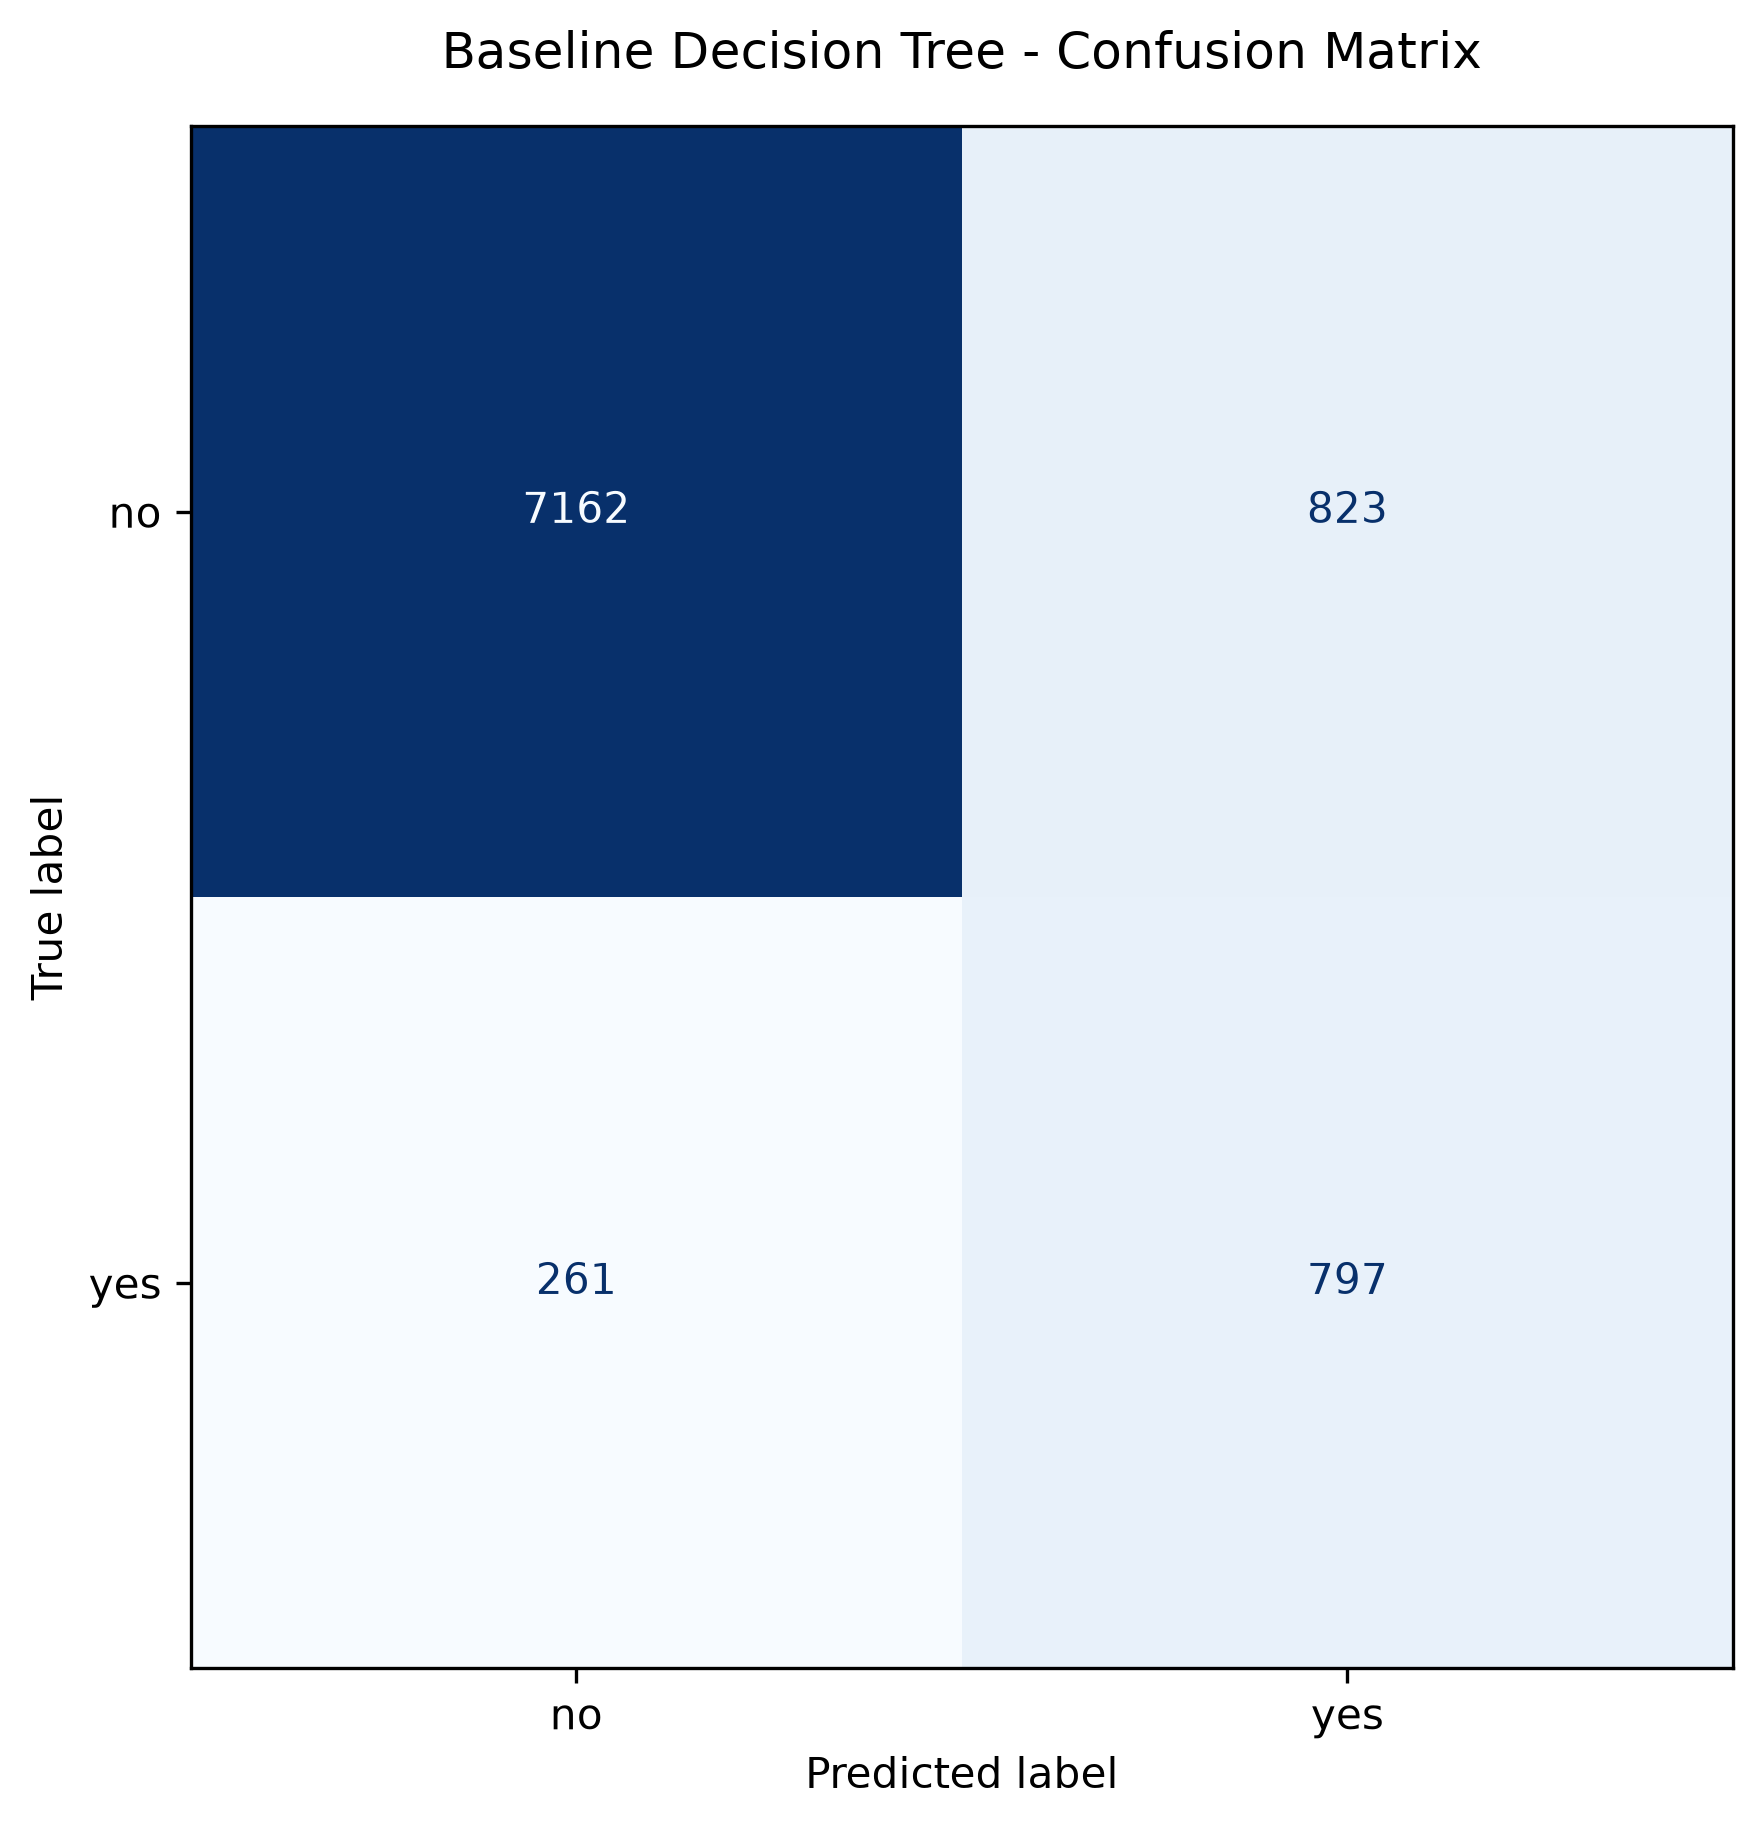

In [5]:
metric_names = ['accuracy', 'error_rate', 'precision', 'recall', 'f1_score', 'roc_auc', 'train_accuracy', 'test_accuracy']
display(metrics.loc[metric_names].astype(float).rename('Result').to_frame().style.format('{:.6f}'))
display(Image(filename=str(FIGURES_DIR / 'trung_confusion_matrix.png'), width=650))

## 5. Comparison of Results

Model,accuracy,error_rate,precision,recall,f1_score,roc_auc,depth,leaves,nodes
Hoang Baseline,0.8737,0.1263,0.4611,0.4707,0.4659,0.6989,34,2876,5751
Hau Tuned,0.9005,0.0995,0.5954,0.4660,0.5228,0.9005,20,339,677
Kiet Pruned Entropy,0.9045,0.0955,0.6036,0.5340,0.5667,0.9114,19,143,285
Trung Weighted + Tuned,0.8801,0.1199,0.4920,0.7533,0.5952,0.8945,20,390,779


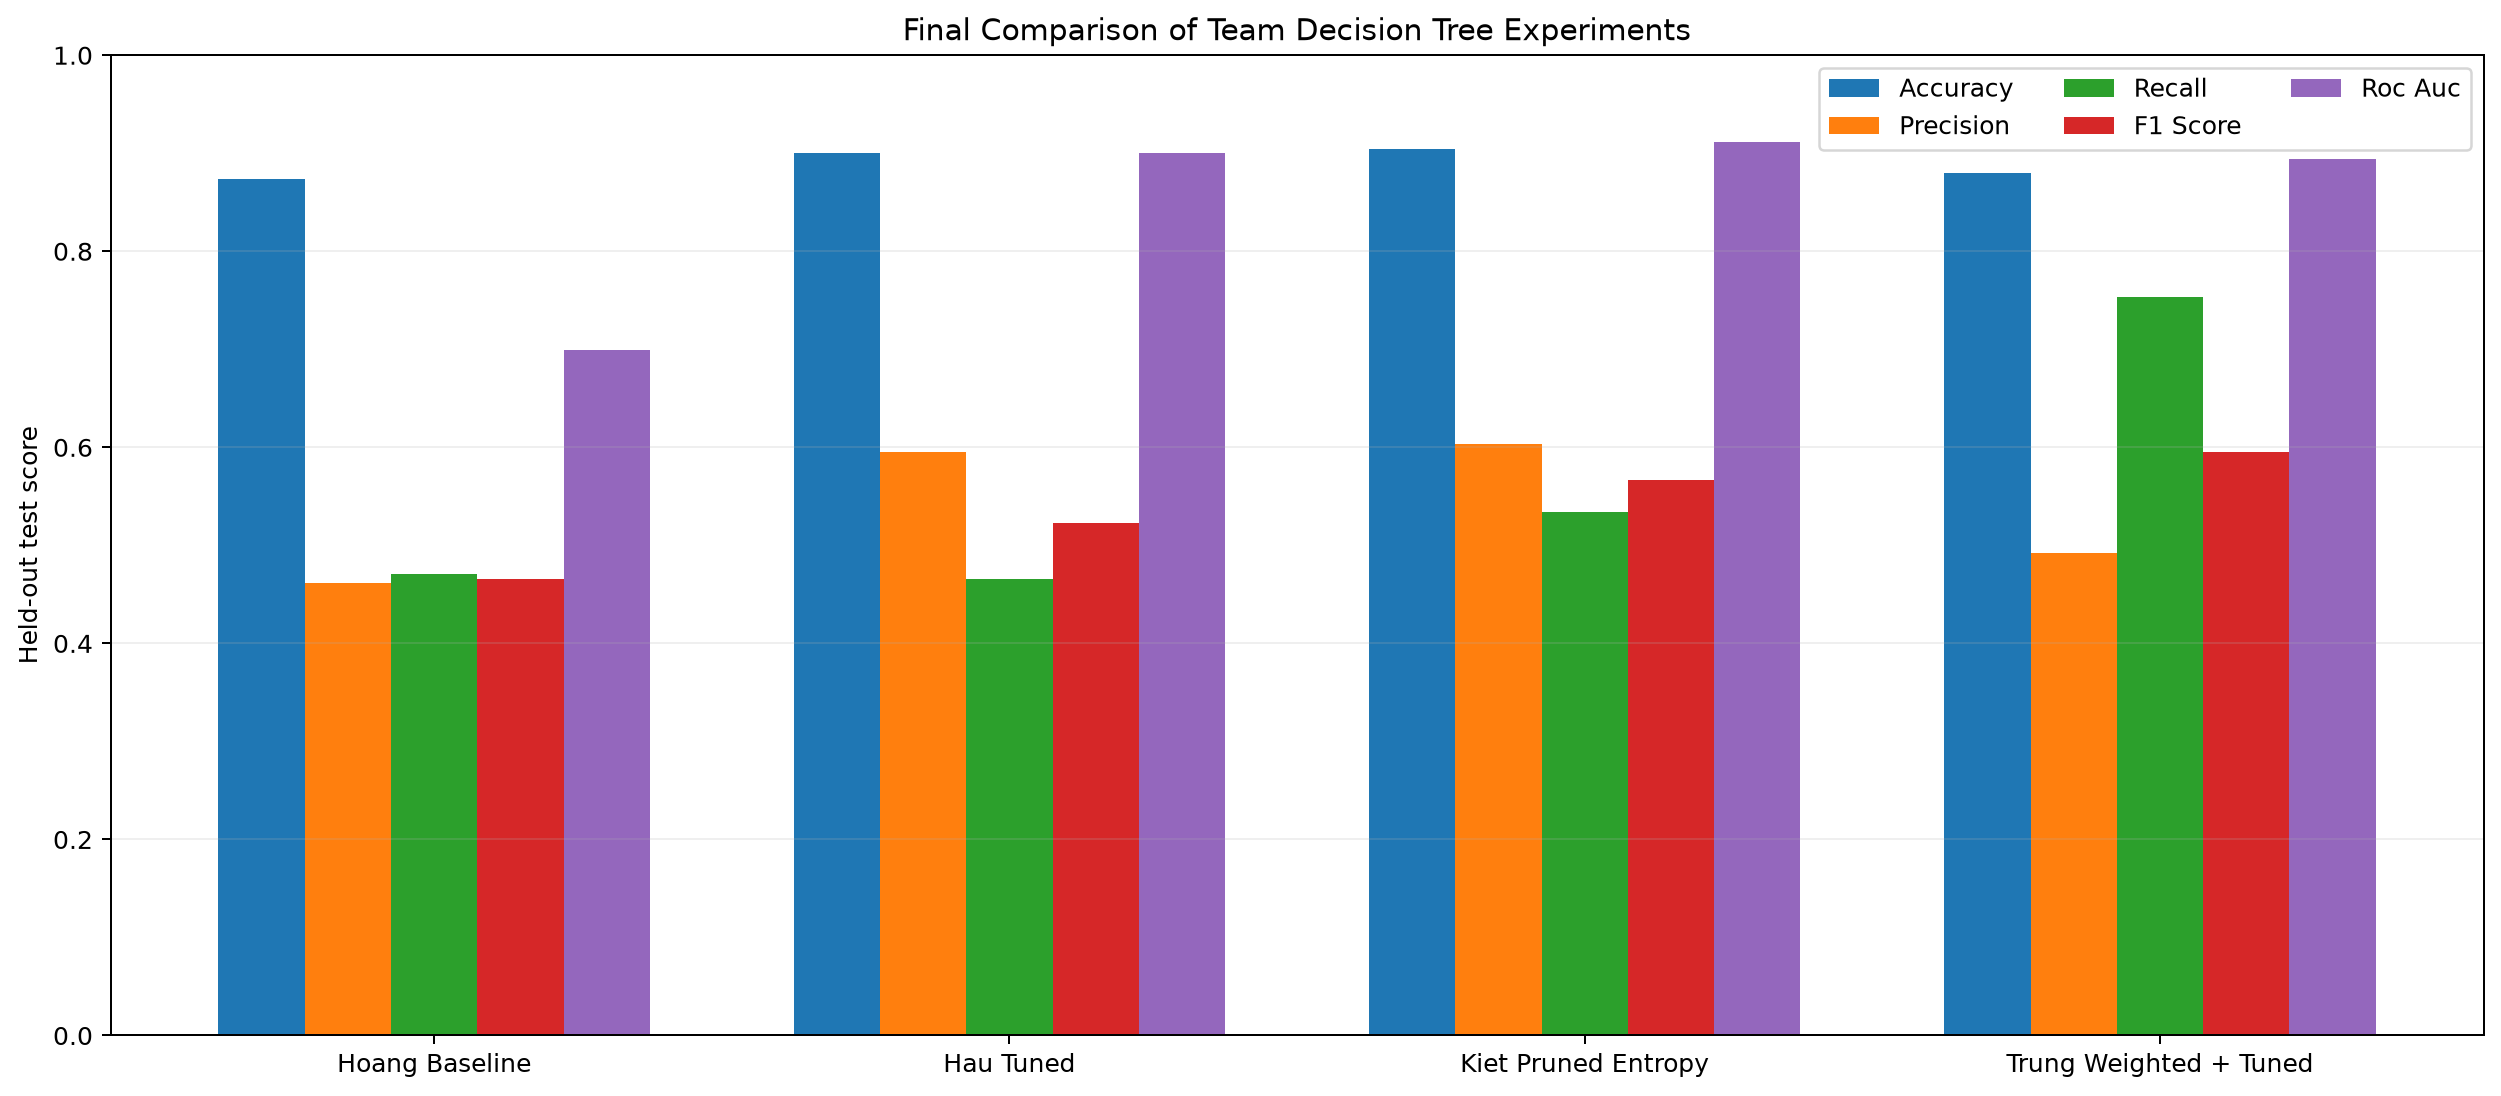

In [6]:
display(
    comparison.style
    .format({name: '{:.4f}' for name in ['accuracy', 'error_rate', 'precision', 'recall', 'f1_score', 'roc_auc']})
    .background_gradient(subset=['recall', 'f1_score', 'roc_auc'], cmap='Greens')
    .hide(axis='index')
)
display(Image(filename=str(FIGURES_DIR / 'team_model_comparison.png'), width=1100))

## 6. Conclusion

In [7]:
baseline = comparison.loc[comparison['Model'].eq('Hoang Baseline')].iloc[0]
trung = comparison.loc[comparison['Model'].eq('Trung Weighted + Tuned')].iloc[0]
best_f1 = comparison.sort_values('f1_score', ascending=False).iloc[0]
display(Markdown(f'''
- Weight được khóa bằng CV là **{summary['selected_class_weight_label']}**.
- Structural controls được khóa trước weight search: **{structural_parameters}**.
- So với baseline, Accuracy thay đổi **{trung.accuracy - baseline.accuracy:+.4f}**, Recall `yes` **{trung.recall - baseline.recall:+.4f}**, F1 `yes` **{trung.f1_score - baseline.f1_score:+.4f}**.
- Train Accuracy là **{float(metrics['train_accuracy']):.4f}**; structural regularization giữ train-test gap nhỏ thay vì để weighted tree tăng trưởng không giới hạn.
- Mô hình có F1 `yes` cao nhất trong bảng chính là **{best_f1.Model}** với F1 **{best_f1.f1_score:.4f}**.
- Trong triển khai thực tế, ưu tiên Recall nếu chi phí bỏ sót khách hàng tiềm năng cao; ưu tiên Precision nếu chi phí gọi nhầm cao.
'''))


- Weight được khóa bằng CV là **no=1, yes=3**.
- Structural controls được khóa trước weight search: **{'max_depth': 20, 'min_samples_leaf': 10, 'min_samples_split': 100}**.
- So với baseline, Accuracy thay đổi **+0.0064**, Recall `yes` **+0.2826**, F1 `yes` **+0.1294**.
- Train Accuracy là **0.8941**; structural regularization giữ train-test gap nhỏ thay vì để weighted tree tăng trưởng không giới hạn.
- Mô hình có F1 `yes` cao nhất trong bảng chính là **Trung Weighted + Tuned** với F1 **0.5952**.
- Trong triển khai thực tế, ưu tiên Recall nếu chi phí bỏ sót khách hàng tiềm năng cao; ưu tiên Precision nếu chi phí gọi nhầm cao.
